# Track A 종합 분석 — ACTES 자전거 에르고미터 운동 데이터셋

PhysioNet ACTES 데이터셋을 기반으로 파워 구간별 HRV(rMSSD, SDNN)를 산출하고,
혼합효과모형을 통해 파워-HRV 용량-반응 관계를 정량적으로 분석한다.

**분석 흐름:**
1. 데이터 로딩 및 품질 점검 (RR 이상치 필터링)
2. 파워 구간 세분화 (Rest / Low / Moderate / High)
3. 구간별 HRV 산출 (rMSSD, SDNN, ln_rMSSD)
4. EDA 시각화 (박스플롯, 산점도, 시계열, 스포츠 비교)
5. 통계 모형 (OLS, 랜덤절편, 랜덤기울기 혼합효과모형)
6. 30초 윈도우 용량-반응 곡선 및 시차 분석
7. 처리 데이터 저장 및 결과 출력

## 0. 환경 설정

In [1]:
import sys
import os
import warnings

# 프로젝트 루트를 모듈 탐색 경로에 추가
sys.path.insert(0, '..')

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as sp_stats
import statsmodels.formula.api as smf

# 프로젝트 내부 모듈
from src.metrics.hrv_features import rmssd, sdnn, ln_rmssd
from src.data.preprocess import filter_rr_outliers
from src.stats.mixed_effects import (
    fit_random_intercept,
    fit_random_slope,
    extract_model_metrics,
    compare_models,
    plot_model_comparison,
)

# 경고 필터링 (수렴 경고 등)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# 재현성을 위한 시드 고정
np.random.seed(42)

In [2]:
# 경로 상수
PROJECT_ROOT = os.path.abspath('..')
RAW_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw', 'track_A')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'reports', 'figures')

# 출력 디렉토리 보장
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# HRV 산출 최소 비트 수 (운동 구간은 일상 기록보다 짧으므로 30으로 하향)
MIN_BEAT_COUNT = 30

# 구분선 출력 헬퍼
def section_header(title: str) -> None:
    """섹션 구분선과 제목을 출력한다."""
    line = "=" * 72
    print(f"\n{line}")
    print(f"  {title}")
    print(f"{line}\n")

## 1. 데이터 로딩 및 품질 점검

PhysioNet ACTES 데이터셋의 피험자 정보와 측정 데이터를 로딩하고,
RR 이상치를 피험자별 중앙값 ±20% 기준으로 필터링한다.

In [3]:
section_header('1. 데이터 로딩 및 품질 점검')

# 1-1. CSV 로딩
subject_info = pd.read_csv(os.path.join(RAW_DIR, 'subject-info.csv'))
test_measure = pd.read_csv(os.path.join(RAW_DIR, 'test_measure.csv'))

print(f'[피험자 정보] 행: {len(subject_info)}, 열: {list(subject_info.columns)}')
print(f'[측정 데이터] 행: {len(test_measure):,}, 열: {list(test_measure.columns)}')
print()

# 1-2. 병합 (ID 기준)
df = test_measure.merge(subject_info, on='ID', how='left')
print(f'[병합 결과] 행: {len(df):,}, 열: {list(df.columns)}')
print()

# 1-3. 피험자별 기초 통계
print('── 피험자별 기초 통계 ──')
subj_stats = df.groupby('ID').agg(
    n_beats=('RR', 'count'),
    RR_mean=('RR', 'mean'),
    RR_median=('RR', 'median'),
    RR_std=('RR', 'std'),
    power_max=('power', 'max'),
    time_min=('time', 'min'),
    time_max=('time', 'max'),
    sport=('sport', 'first'),
    P_vt1=('P_vt1', 'first'),
    P_vt2=('P_vt2', 'first'),
).reset_index()
print(subj_stats.to_string(index=False))
print()

# 1-4. RR 이상치 필터링 (피험자별 중앙값 ±20%)
print('── RR 이상치 필터링 (중앙값 ±20%) ──')
rr_before = df['RR'].notna().sum()

# 피험자별로 필터링 적용
filtered_rr_list = []
for subj_id, grp in df.groupby('ID'):
    filtered = filter_rr_outliers(grp['RR'], threshold=0.20)
    filtered_rr_list.append(filtered)

df['RR_filtered'] = pd.concat(filtered_rr_list).sort_index()
rr_after = df['RR_filtered'].notna().sum()
rr_removed = rr_before - rr_after
print(f'  필터링 전: {rr_before:,}개')
print(f'  필터링 후: {rr_after:,}개')
print(f'  제거된 이상치: {rr_removed:,}개 ({rr_removed / rr_before * 100:.1f}%)')


  1. 데이터 로딩 및 품질 점검

[피험자 정보] 행: 18, 열: ['ID', 'age', 'Weight', 'Height', 'P_vt1', 'P_vt2', 'sport']
[측정 데이터] 행: 52,062, 열: ['ID', 'time', 'RR', 'VO2', 'power']

[병합 결과] 행: 52,062, 열: ['ID', 'time', 'RR', 'VO2', 'power', 'age', 'Weight', 'Height', 'P_vt1', 'P_vt2', 'sport']

── 피험자별 기초 통계 ──
 ID  n_beats    RR_mean  RR_median     RR_std  power_max  time_min  time_max     sport  P_vt1  P_vt2
  1     2403 411.081149      380.0 121.157152        170  -130.840   856.316   fencing     50    140
  2     2000 474.040000      416.0 180.730679        140  -219.872   727.480   fencing     80    127
  3     3443 461.095556      440.0 115.570278        305  -182.272  1404.164   fencing    155    300
  4     3694 419.812669      412.0  96.588612        305  -183.676  1366.552   fencing    215    275
  5     3594 435.331107      400.0 140.756819        275  -180.324  1383.428   fencing    110    172
  6     2683 475.455833      440.0 347.787239        245  -184.444  1090.168   fencing    131    186

## 2. 파워 구간 세분화

파워(power)와 개인별 환기역치(P_vt1, P_vt2)를 기준으로 파워 구간을 분류한다.
- **Rest**: power == 0
- **Low**: 0 < power <= P_vt1
- **Moderate**: P_vt1 < power <= P_vt2
- **High**: power > P_vt2

In [4]:
section_header('2. 파워 구간 세분화')

def assign_power_zone(row: pd.Series) -> str:
    """파워와 개인별 환기역치를 기준으로 파워 구간을 분류한다."""
    p = row["power"]
    vt1 = row["P_vt1"]
    vt2 = row["P_vt2"]
    if p == 0:
        return "Rest"
    elif p <= vt1:
        return "Low"
    elif p <= vt2:
        return "Moderate"
    else:
        return "High"

df['power_zone'] = df.apply(assign_power_zone, axis=1)

# 구간 순서 지정 (시각화용)
zone_order = ["Rest", "Low", "Moderate", "High"]
df['power_zone'] = pd.Categorical(df['power_zone'], categories=zone_order, ordered=True)

# 구간별 통계
zone_counts = df.groupby('power_zone', observed=True).agg(
    n_beats=('RR_filtered', 'count'),
    n_valid=('RR_filtered', lambda x: x.notna().sum()),
    power_mean=('power', 'mean'),
    power_std=('power', 'std'),
    RR_mean=('RR_filtered', 'mean'),
    RR_std=('RR_filtered', 'std'),
).reset_index()
print('── 파워 구간별 통계 ──')
print(zone_counts.to_string(index=False))
print()

# 피험자 x 구간별 비트 수
cross_tab = df.groupby(['ID', 'power_zone'], observed=True)['RR_filtered'].apply(
    lambda x: x.notna().sum()
).unstack(fill_value=0)
print('── 피험자별 구간 내 유효 비트 수 ──')
print(cross_tab.to_string())


  2. 파워 구간 세분화



── 파워 구간별 통계 ──
power_zone  n_beats  n_valid  power_mean  power_std    RR_mean    RR_std
      Rest     6918     6918    0.000000   0.000000 416.526164 54.187319
       Low    11375    11375   84.657681  40.023586 451.246418 33.514396
  Moderate    12198    12198  167.535206  61.317351 379.795704 31.334081
      High     5099     5099  208.274506  54.479057 337.996470 15.442295

── 피험자별 구간 내 유효 비트 수 ──
power_zone  Rest   Low  Moderate  High
ID                                    
1            400   198      1016   295
2            267   540       505    37
3            346   893       999     0
4            422  1719       489     1
5            421   401       594  1213
6            272   559       606   174
7            304   443       297   628
8            343   557       452    95
9            639   193       806   747
10           518   231       672   477
11           383  1371       547     3
12           369   885      1085     1
13           447   532      1248   210
14       

## 3. 구간별 HRV 산출 (rMSSD, SDNN, ln_rMSSD)

각 피험자의 파워 구간별로 HRV 지표(rMSSD, SDNN, ln_rMSSD)를 산출한다.
최소 비트 수(`MIN_BEAT_COUNT=30`) 미만인 구간은 NA 처리한다.

In [5]:
section_header('3. 구간별 HRV 산출 (rMSSD, SDNN, ln_rMSSD)')

hrv_records = []

for (subj_id, zone), grp in df.groupby(['ID', 'power_zone'], observed=True):
    nn = grp['RR_filtered'].dropna().values
    rmssd_val = rmssd(nn, min_count=MIN_BEAT_COUNT)
    sdnn_val = sdnn(nn, min_count=MIN_BEAT_COUNT)
    ln_rmssd_val = ln_rmssd(nn, min_count=MIN_BEAT_COUNT)
    power_mean = grp['power'].mean()
    power_std = grp['power'].std()
    sport = grp['sport'].iloc[0]
    age = grp['age'].iloc[0]
    hrv_records.append({
        'subject': subj_id,
        'power_zone': zone,
        'n_beats': len(nn),
        'power_mean': round(power_mean, 1),
        'power_std': round(power_std, 1) if not np.isnan(power_std) else 0.0,
        'rmssd': rmssd_val,
        'sdnn': sdnn_val,
        'ln_rmssd': ln_rmssd_val,
        'sport': sport,
        'age': age,
    })

hrv_df = pd.DataFrame(hrv_records)
hrv_df['power_zone'] = pd.Categorical(
    hrv_df['power_zone'], categories=zone_order, ordered=True
)

print('── HRV 산출 결과 (전체) ──')
print(hrv_df.to_string(index=False))
print()

# HRV가 산출된 행만 필터
hrv_valid = hrv_df.dropna(subset=['rmssd']).copy()
print(f'  유효 HRV 산출 건수: {len(hrv_valid)} / {len(hrv_df)}')
print(f'  (min_count={MIN_BEAT_COUNT} 미만으로 제외된 건수: {len(hrv_df) - len(hrv_valid)})')
print()

# 구간별 HRV 요약
if not hrv_valid.empty:
    hrv_summary = hrv_valid.groupby('power_zone', observed=True).agg(
        n=('rmssd', 'count'),
        rmssd_mean=('rmssd', 'mean'),
        rmssd_std=('rmssd', 'std'),
        rmssd_median=('rmssd', 'median'),
        sdnn_mean=('sdnn', 'mean'),
        sdnn_std=('sdnn', 'std'),
        ln_rmssd_mean=('ln_rmssd', 'mean'),
        ln_rmssd_std=('ln_rmssd', 'std'),
    ).reset_index()
    print('── 파워 구간별 HRV 요약 ──')
    print(hrv_summary.to_string(index=False))


  3. 구간별 HRV 산출 (rMSSD, SDNN, ln_rMSSD)

── HRV 산출 결과 (전체) ──
 subject power_zone  n_beats  power_mean  power_std     rmssd      sdnn  ln_rmssd     sport  age
       1       Rest      400         0.0        0.0 11.451106 43.908673  2.438086   fencing   15
       1        Low      198        50.0        0.0  4.188454 11.152764  1.432332   fencing   15
       1   Moderate     1016       104.6       25.5  4.726198 33.310747  1.553121   fencing   15
       1       High      295       160.2        7.1  3.695925  3.222657  1.307231   fencing   15
       2       Rest      267         0.0        0.0  6.716605 50.452715  1.904583   fencing   15
       2        Low      540        60.5       12.5  5.343836 30.254137  1.675944   fencing   15
       2   Moderate      505       110.4       12.2  4.400577 13.013114  1.481736   fencing   15
       2       High       37       140.0        0.0  4.371626  3.068781  1.475135   fencing   15
       3       Rest      346         0.0        0.0 10.889697 51

## 4. EDA 시각화

파워 구간별 HRV 분포, 산점도, 시계열, 스포츠 종목 비교를 시각화한다.

### 4-1. 파워 구간별 rMSSD 박스플롯

  [4-1] 파워 구간별 rMSSD 박스플롯 생성 중...


C:\Users\lynn2\AppData\Local\Temp\ipykernel_27348\1297875896.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.6)


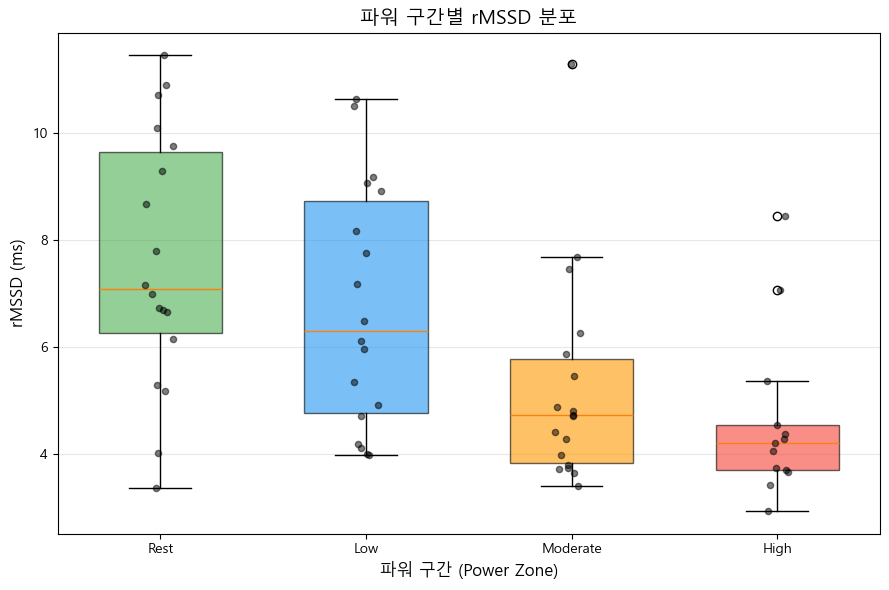

    저장 완료: C:\dev\soccer_rnd\reports\figures\track_A_hrv_by_power_zone.png


In [6]:
# 한글 폰트 설정 시도
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

print('  [4-1] 파워 구간별 rMSSD 박스플롯 생성 중...')
fig1, ax1 = plt.subplots(figsize=(9, 6))

box_data = []
box_labels = []
for zone in zone_order:
    vals = hrv_valid.loc[hrv_valid['power_zone'] == zone, 'rmssd'].dropna().values
    if len(vals) > 0:
        box_data.append(vals)
        box_labels.append(zone)

if box_data:
    bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.6)
    colors_box = ["#4CAF50", "#2196F3", "#FF9800", "#F44336"]
    for patch, color in zip(bp["boxes"], colors_box[:len(bp["boxes"])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    for i, (vals, label) in enumerate(zip(box_data, box_labels)):
        x_jitter = np.random.normal(i + 1, 0.04, size=len(vals))
        ax1.scatter(x_jitter, vals, alpha=0.5, s=20, color="black", zorder=3)

ax1.set_xlabel("파워 구간 (Power Zone)", fontsize=12)
ax1.set_ylabel("rMSSD (ms)", fontsize=12)
ax1.set_title("파워 구간별 rMSSD 분포", fontsize=14)
ax1.grid(axis="y", alpha=0.3)
fig1.tight_layout()
fig1_path = os.path.join(FIGURES_DIR, "track_A_hrv_by_power_zone.png")
fig1.savefig(fig1_path, dpi=150)
plt.show()
print(f'    저장 완료: {fig1_path}')

### 4-2. rMSSD vs 평균 파워 산점도 (피험자별 색상)

  [4-2] rMSSD vs 평균 파워 산점도 생성 중...


C:\Users\lynn2\AppData\Local\Temp\ipykernel_27348\2504361504.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(subjects))


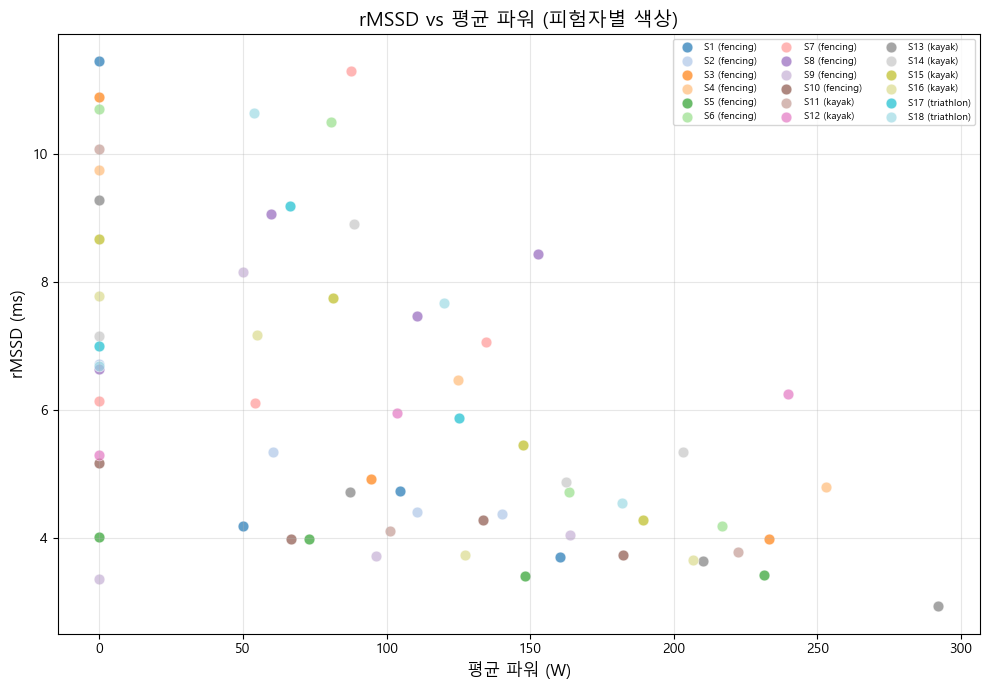

    저장 완료: C:\dev\soccer_rnd\reports\figures\track_A_rmssd_vs_power_scatter.png


In [7]:
print('  [4-2] rMSSD vs 평균 파워 산점도 생성 중...')
fig2, ax2 = plt.subplots(figsize=(10, 7))

subjects = hrv_valid['subject'].unique()
cmap = plt.cm.get_cmap('tab20', len(subjects))

for idx, subj in enumerate(sorted(subjects)):
    mask = hrv_valid['subject'] == subj
    sub_data = hrv_valid[mask]
    sport = sub_data['sport'].iloc[0]
    ax2.scatter(
        sub_data['power_mean'], sub_data['rmssd'],
        color=cmap(idx), label=f'S{subj} ({sport})',
        s=60, alpha=0.7, edgecolors="white", linewidth=0.5,
    )

ax2.set_xlabel("평균 파워 (W)", fontsize=12)
ax2.set_ylabel("rMSSD (ms)", fontsize=12)
ax2.set_title("rMSSD vs 평균 파워 (피험자별 색상)", fontsize=14)
ax2.legend(fontsize=7, ncol=3, loc="upper right", framealpha=0.8)
ax2.grid(alpha=0.3)
fig2.tight_layout()
fig2_path = os.path.join(FIGURES_DIR, "track_A_rmssd_vs_power_scatter.png")
fig2.savefig(fig2_path, dpi=150)
plt.show()
print(f'    저장 완료: {fig2_path}')

### 4-3. 샘플 피험자 3명의 RR 및 파워 시계열

  [4-3] 샘플 피험자 RR/파워 시계열 생성 중...


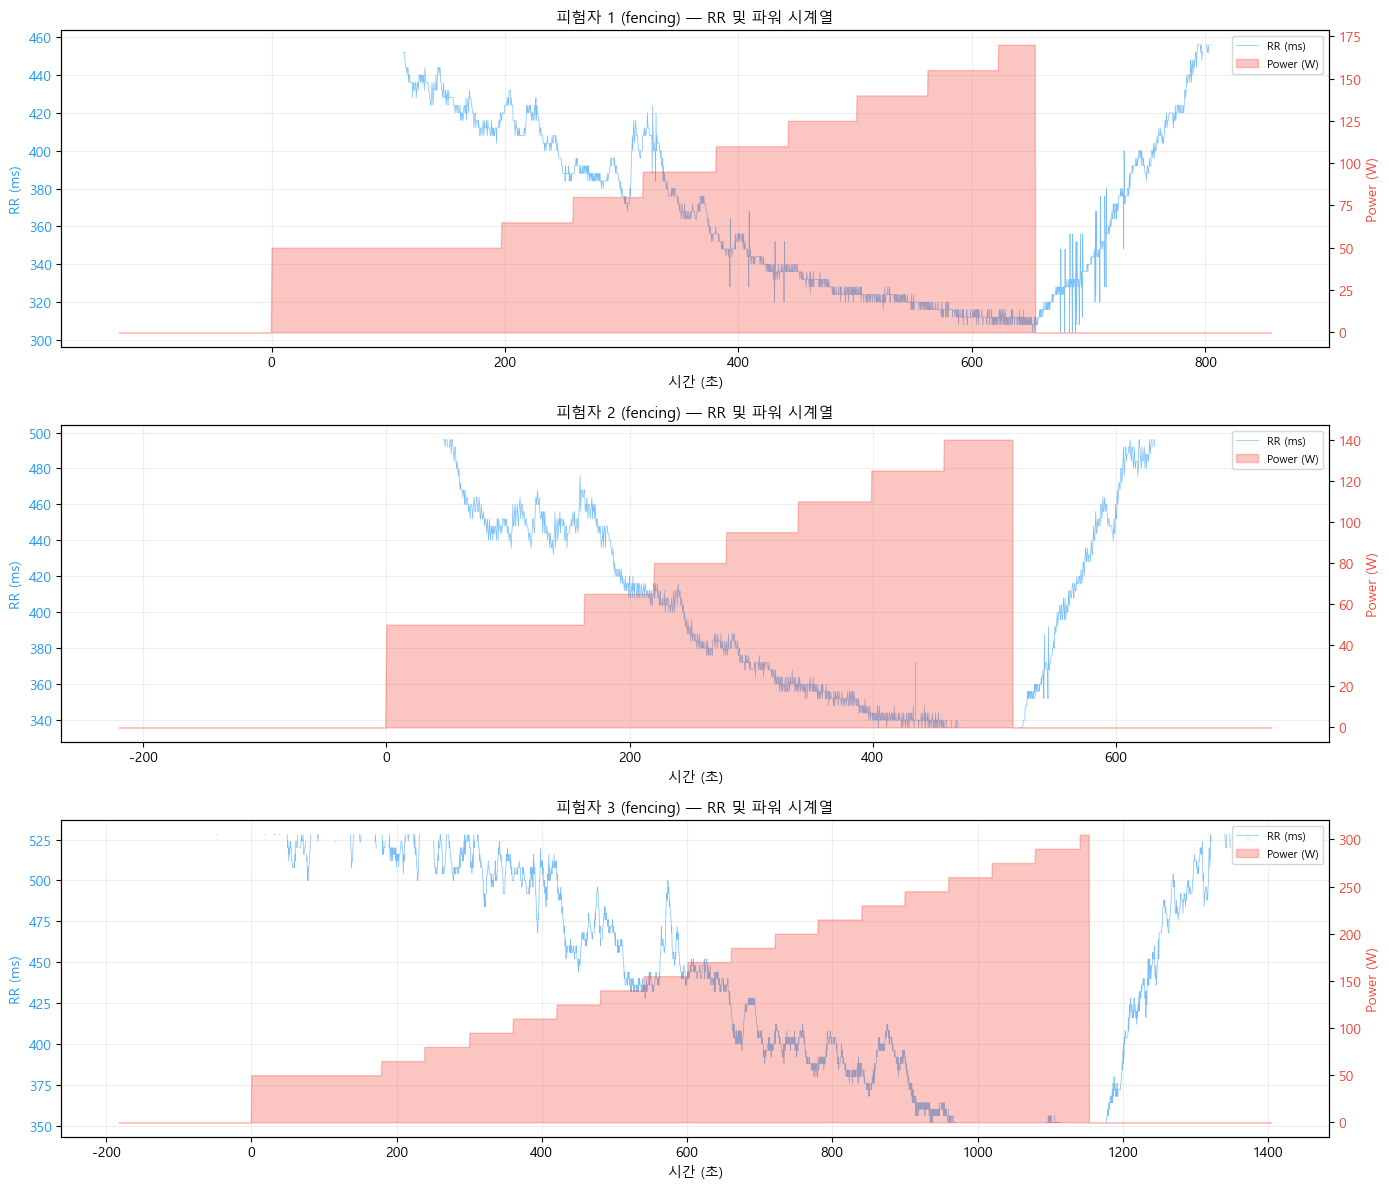

    저장 완료: C:\dev\soccer_rnd\reports\figures\track_A_rr_timeseries_sample.png


In [8]:
print('  [4-3] 샘플 피험자 RR/파워 시계열 생성 중...')
sample_subjects = sorted(df['ID'].unique())[:3]
fig3, axes3 = plt.subplots(len(sample_subjects), 1, figsize=(14, 4 * len(sample_subjects)))
if len(sample_subjects) == 1:
    axes3 = [axes3]

for ax_idx, subj_id in enumerate(sample_subjects):
    ax = axes3[ax_idx]
    subj_data = df[df['ID'] == subj_id].sort_values('time')
    ax.plot(subj_data['time'], subj_data['RR_filtered'], color='#2196F3',
            alpha=0.6, linewidth=0.5, label='RR (ms)')
    ax.set_ylabel('RR (ms)', color='#2196F3', fontsize=10)
    ax.tick_params(axis='y', labelcolor='#2196F3')
    ax2_twin = ax.twinx()
    ax2_twin.fill_between(subj_data['time'], subj_data['power'],
                          alpha=0.3, color='#F44336', label='Power (W)')
    ax2_twin.set_ylabel('Power (W)', color='#F44336', fontsize=10)
    ax2_twin.tick_params(axis='y', labelcolor='#F44336')
    sport_label = subj_data['sport'].iloc[0]
    ax.set_title(f'피험자 {subj_id} ({sport_label}) — RR 및 파워 시계열', fontsize=11)
    ax.set_xlabel('시간 (초)', fontsize=10)
    ax.grid(alpha=0.2)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

fig3.tight_layout()
fig3_path = os.path.join(FIGURES_DIR, "track_A_rr_timeseries_sample.png")
fig3.savefig(fig3_path, dpi=150)
plt.show()
print(f'    저장 완료: {fig3_path}')

### 4-4. 스포츠 종목별 HRV 비교

  [4-4] 스포츠 종목별 HRV 비교 생성 중...


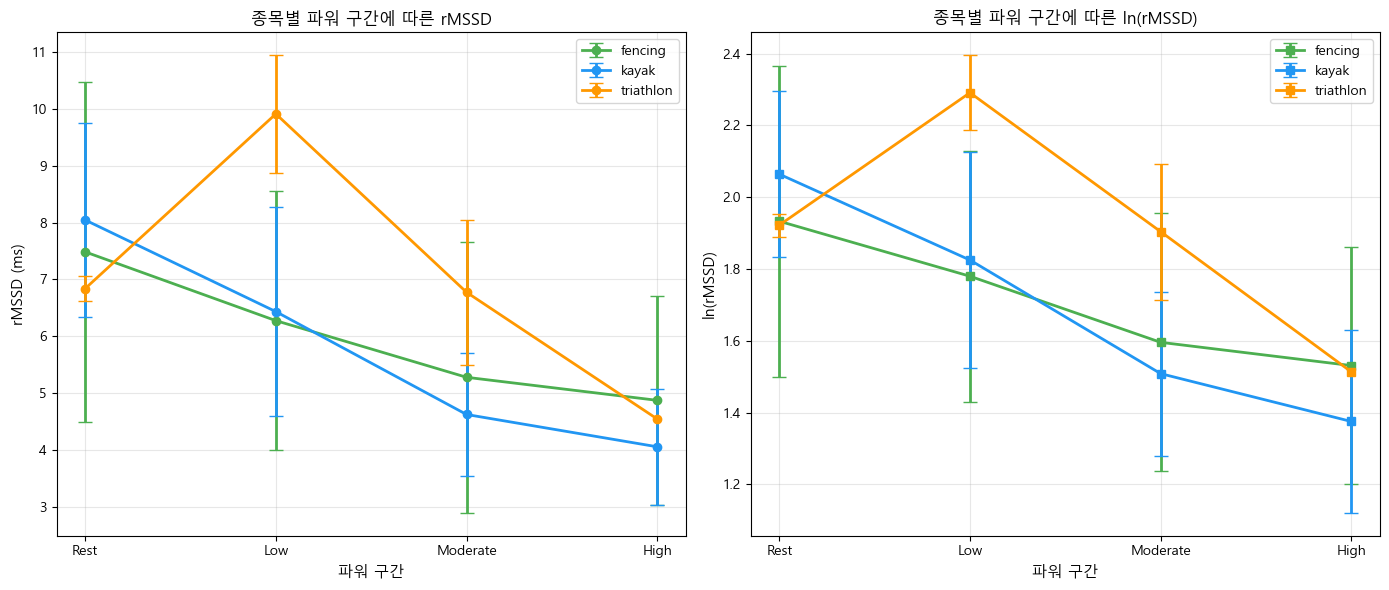

    저장 완료: C:\dev\soccer_rnd\reports\figures\track_A_sport_comparison.png


In [9]:
print('  [4-4] 스포츠 종목별 HRV 비교 생성 중...')
fig4, axes4 = plt.subplots(1, 2, figsize=(14, 6))

sports = ["fencing", "kayak", "triathlon"]
sport_colors = {"fencing": "#4CAF50", "kayak": "#2196F3", "triathlon": "#FF9800"}

# 4-4a: 종목별 rMSSD 구간 비교
for sport in sports:
    sport_data = hrv_valid[hrv_valid['sport'] == sport]
    sport_summary = sport_data.groupby('power_zone', observed=True)['rmssd'].agg(
        ['mean', 'std', 'count']
    ).reset_index()
    sport_summary['power_zone'] = pd.Categorical(
        sport_summary['power_zone'], categories=zone_order, ordered=True
    )
    sport_summary = sport_summary.sort_values('power_zone')
    axes4[0].errorbar(
        [z for z in sport_summary['power_zone']],
        sport_summary['mean'], yerr=sport_summary['std'],
        marker='o', capsize=5, label=sport,
        color=sport_colors[sport], linewidth=2,
    )

axes4[0].set_xlabel("파워 구간", fontsize=11)
axes4[0].set_ylabel("rMSSD (ms)", fontsize=11)
axes4[0].set_title("종목별 파워 구간에 따른 rMSSD", fontsize=12)
axes4[0].legend(fontsize=10)
axes4[0].grid(alpha=0.3)

# 4-4b: 종목별 ln_rMSSD 구간 비교
for sport in sports:
    sport_data = hrv_valid[hrv_valid['sport'] == sport]
    sport_summary = sport_data.groupby('power_zone', observed=True)['ln_rmssd'].agg(
        ['mean', 'std', 'count']
    ).reset_index()
    sport_summary['power_zone'] = pd.Categorical(
        sport_summary['power_zone'], categories=zone_order, ordered=True
    )
    sport_summary = sport_summary.sort_values('power_zone')
    axes4[1].errorbar(
        [z for z in sport_summary['power_zone']],
        sport_summary['mean'], yerr=sport_summary['std'],
        marker='s', capsize=5, label=sport,
        color=sport_colors[sport], linewidth=2,
    )

axes4[1].set_xlabel("파워 구간", fontsize=11)
axes4[1].set_ylabel("ln(rMSSD)", fontsize=11)
axes4[1].set_title("종목별 파워 구간에 따른 ln(rMSSD)", fontsize=12)
axes4[1].legend(fontsize=10)
axes4[1].grid(alpha=0.3)

fig4.tight_layout()
fig4_path = os.path.join(FIGURES_DIR, "track_A_sport_comparison.png")
fig4.savefig(fig4_path, dpi=150)
plt.show()
print(f'    저장 완료: {fig4_path}')

## 5. 통계 분석

OLS, 랜덤절편 혼합효과모형, 랜덤기울기 혼합효과모형을 적합하고 비교한다.
- **종속변수**: rMSSD
- **설명변수**: power_mean (연속), power_zone (범주)
- **랜덤효과**: subject (피험자)

### 5-1. OLS 회귀: rMSSD ~ C(power_zone)

In [10]:
section_header('5. 통계 분석')

# 분석용 데이터 준비
stat_df = hrv_valid.copy()
stat_df['subject'] = stat_df['subject'].astype(str)

# 5-1. OLS
print('── 5-1. OLS 회귀: rMSSD ~ C(power_zone) ──')
try:
    ols_model = smf.ols("rmssd ~ C(power_zone, Treatment(reference='Rest'))", data=stat_df)
    ols_result = ols_model.fit()
    print(ols_result.summary())
    print()
    print('── ANOVA (파워 구간 효과 검정) ──')
    from statsmodels.stats.anova import anova_lm
    anova_table = anova_lm(ols_result)
    print(anova_table)
except Exception as e:
    print(f'  OLS 적합 실패: {e}')
    ols_result = None


  5. 통계 분석

── 5-1. OLS 회귀: rMSSD ~ C(power_zone) ──
                            OLS Regression Results                            
Dep. Variable:                  rmssd   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     6.814
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           0.000474
Time:                        02:27:14   Log-Likelihood:                -142.95
No. Observations:                  67   AIC:                             293.9
Df Residuals:                      63   BIC:                             302.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

### 5-2. 혼합효과모형 (랜덤 절편): rMSSD ~ power_mean + (1|subject)

In [11]:
print('── 5-2. 혼합효과모형 (랜덤 절편) ──')
try:
    me_ri = fit_random_intercept(
        formula='rmssd ~ power_mean', data=stat_df, group_col='subject',
    )
    print(me_ri.summary())
    print()
    ri_metrics = extract_model_metrics(me_ri, stat_df, 'rmssd')
    print(f"  AIC: {ri_metrics['aic']:.2f}")
    print(f"  BIC: {ri_metrics['bic']:.2f}")
    print(f"  MAE: {ri_metrics['mae']:.2f}")
    print(f"  RMSE: {ri_metrics['rmse']:.2f}")
    print(f"  고정효과: {ri_metrics['fixed_effects']}")
    print(f"  고정효과 p-value: {ri_metrics['fixed_pvalues']}")
    print(f"  랜덤효과 분산: {ri_metrics['random_effects_var']}")
except Exception as e:
    print(f'  랜덤 절편 모형 적합 실패: {e}')
    me_ri = None

── 5-2. 혼합효과모형 (랜덤 절편) ──
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: rmssd    
No. Observations: 67      Method:             REML     
No. Groups:       18      Scale:              3.4600   
Min. group size:  3       Log-Likelihood:     -145.1442
Max. group size:  4       Converged:          Yes      
Mean group size:  3.7                                  
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     7.743    0.405 19.105 0.000  6.948  8.537
power_mean   -0.016    0.003 -5.578 0.000 -0.022 -0.010
Group Var     0.561    0.307                           


  AIC: 296.29
  BIC: 302.90
  MAE: 1.41
  RMSE: 1.74
  고정효과: {'Intercept': 7.742670935110105, 'power_mean': -0.016090942388092767}
  고정효과 p-value: {'Intercept': 2.3012838300730414e-81, 'power_mean': 2.4264149953508416e-08, 'Group Var': 0.326803957550501

### 5-3. 혼합효과모형 (랜덤 기울기): rMSSD ~ power_mean + (1 + power_mean|subject)

In [12]:
print('── 5-3. 혼합효과모형 (랜덤 기울기) ──')
try:
    me_rs = fit_random_slope(
        formula='rmssd ~ power_mean', data=stat_df,
        group_col='subject', slope_var='power_mean',
    )
    if me_rs is not None:
        print(me_rs.summary())
        print()
        rs_metrics = extract_model_metrics(me_rs, stat_df, 'rmssd')
        print(f"  AIC: {rs_metrics['aic']:.2f}")
        print(f"  BIC: {rs_metrics['bic']:.2f}")
        print(f"  MAE: {rs_metrics['mae']:.2f}")
        print(f"  RMSE: {rs_metrics['rmse']:.2f}")
        print(f"  고정효과: {rs_metrics['fixed_effects']}")
        print(f"  고정효과 p-value: {rs_metrics['fixed_pvalues']}")
        print(f"  랜덤효과 분산: {rs_metrics['random_effects_var']}")
    else:
        print('  랜덤 기울기 모형 수렴 실패 — 랜덤 절편 모형만 사용합니다.')
except Exception as e:
    print(f'  랜덤 기울기 모형 적합 실패: {e}')
    me_rs = None

── 5-3. 혼합효과모형 (랜덤 기울기) ──


              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    rmssd    
No. Observations:     67         Method:                REML     
No. Groups:           18         Scale:                 2.9019   
Min. group size:      3          Log-Likelihood:        -145.2882
Max. group size:      4          Converged:             No       
Mean group size:      3.7                                        
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               7.753    0.527 14.698 0.000  6.719  8.787
power_mean             -0.016    0.003 -5.171 0.000 -0.022 -0.010
Group Var               3.071                                    
Group x power_mean Cov -0.014                                    
power_mean Var          0.000                                    


  AIC: 300.58
  BIC: 3

### 5-4. 모형 비교 (AIC, BIC, MAE, RMSE)

── 5-4. 모형 비교 ──
model_name        aic        bic      mae     rmse
OLS (구간변수) 293.891574 302.710344 1.644998 2.043330
      랜덤절편 296.288370 302.902448 1.411856 1.740284
     랜덤기울기 300.576498 311.599961 1.236392 1.538601



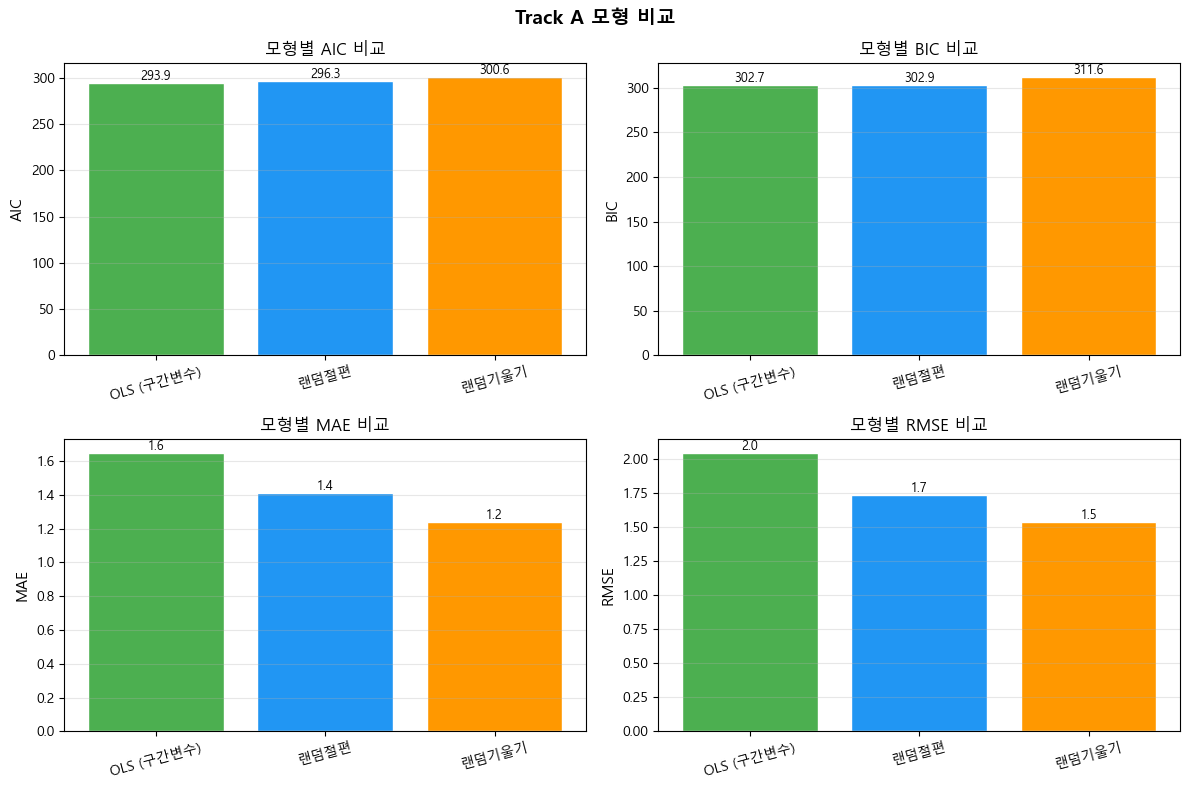

  모형 비교 시각화 저장: C:\dev\soccer_rnd\reports\figures\track_A_model_comparison.png


In [13]:
print('── 5-4. 모형 비교 ──')

models_dict = {}
if me_ri is not None:
    models_dict['랜덤절편'] = me_ri
if me_rs is not None:
    models_dict['랜덤기울기'] = me_rs

if models_dict:
    comparison_df = compare_models(models_dict, stat_df, 'rmssd')
    if ols_result is not None:
        ols_y_true = stat_df['rmssd'].values
        ols_y_pred = ols_result.fittedvalues.values
        ols_residuals = ols_y_true - ols_y_pred
        ols_row = {
            'model_name': 'OLS (구간변수)',
            'aic': ols_result.aic,
            'bic': ols_result.bic,
            'mae': float(np.mean(np.abs(ols_residuals))),
            'rmse': float(np.sqrt(np.mean(ols_residuals ** 2))),
        }
        ols_row_df = pd.DataFrame([ols_row])
        comparison_df = pd.concat([ols_row_df, comparison_df], ignore_index=True)
    print(comparison_df[['model_name', 'aic', 'bic', 'mae', 'rmse']].to_string(index=False))
    print()

    # 모형 비교 시각화
    fig5, axes5 = plt.subplots(2, 2, figsize=(12, 8))
    metrics_to_plot = ['aic', 'bic', 'mae', 'rmse']
    metric_labels = ['AIC', 'BIC', 'MAE', 'RMSE']
    for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
        ax = axes5[idx // 2, idx % 2]
        model_names = comparison_df['model_name'].tolist()
        values = comparison_df[metric].tolist()
        bars = ax.bar(model_names, values,
                       color=['#4CAF50', '#2196F3', '#FF9800'][:len(model_names)],
                       edgecolor='white')
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f'{val:.1f}', ha='center', va='bottom', fontsize=9)
        ax.set_ylabel(label, fontsize=11)
        ax.set_title(f'모형별 {label} 비교', fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=15)
    fig5.suptitle('Track A 모형 비교', fontsize=14, fontweight='bold')
    fig5.tight_layout()
    fig5_path = os.path.join(FIGURES_DIR, 'track_A_model_comparison.png')
    fig5.savefig(fig5_path, dpi=150)
    plt.show()
    print(f'  모형 비교 시각화 저장: {fig5_path}')
else:
    print('  비교 가능한 모형이 없습니다.')

## 6. 추가 분석

30초 윈도우 기반 HRV 용량-반응 곡선과 시차 분석을 수행한다.

### 6-1. 30초 윈도우 HRV 용량-반응 곡선

In [14]:
section_header('6. 추가 분석')
print('── 6-1. 30초 윈도우 HRV 용량-반응 곡선 ──')

window_records = []
for subj_id, subj_data in df.groupby('ID'):
    subj_data = subj_data.sort_values('time').copy()
    sport = subj_data['sport'].iloc[0]
    t_min = subj_data['time'].min()
    t_max = subj_data['time'].max()
    window_size = 30.0
    t_start = t_min
    while t_start < t_max:
        t_end = t_start + window_size
        mask = (subj_data['time'] >= t_start) & (subj_data['time'] < t_end)
        window_data = subj_data[mask]
        if len(window_data) >= MIN_BEAT_COUNT:
            nn = window_data['RR_filtered'].dropna().values
            rmssd_val = rmssd(nn, min_count=MIN_BEAT_COUNT)
            ln_rmssd_val = ln_rmssd(nn, min_count=MIN_BEAT_COUNT)
            power_mean = window_data['power'].mean()
            if rmssd_val is not None:
                window_records.append({
                    'subject': subj_id,
                    't_start': round(t_start, 1),
                    't_end': round(t_end, 1),
                    'power_mean': round(power_mean, 1),
                    'rmssd': round(rmssd_val, 2),
                    'ln_rmssd': round(ln_rmssd_val, 4) if ln_rmssd_val else None,
                    'n_beats': len(nn),
                    'sport': sport,
                })
        t_start += window_size

window_df = pd.DataFrame(window_records)
print(f'  30초 윈도우 생성 수: {len(window_df)}')
print(f'  유효 윈도우 수 (rMSSD 산출 가능): {window_df["rmssd"].notna().sum()}')
print()

if len(window_df) > 0:
    print('── 30초 윈도우 HRV 요약 ──')
    print(window_df.describe().to_string())
    print()
    window_stat = window_df.dropna(subset=['ln_rmssd']).copy()
    window_stat['subject'] = window_stat['subject'].astype(str)
    print('── 용량-반응 혼합효과모형: ln_rMSSD ~ power_mean + (1|subject) ──')
    try:
        dose_model = fit_random_intercept(
            formula='ln_rmssd ~ power_mean', data=window_stat, group_col='subject',
        )
        print(dose_model.summary())
        print()
        dose_metrics = extract_model_metrics(dose_model, window_stat, 'ln_rmssd')
        print(f"  AIC: {dose_metrics['aic']:.2f}")
        print(f"  BIC: {dose_metrics['bic']:.2f}")
        print(f"  MAE: {dose_metrics['mae']:.4f}")
        print(f"  RMSE: {dose_metrics['rmse']:.4f}")
    except Exception as e:
        print(f'  용량-반응 모형 적합 실패: {e}')
        dose_model = None


  6. 추가 분석

── 6-1. 30초 윈도우 HRV 용량-반응 곡선 ──


  30초 윈도우 생성 수: 486
  유효 윈도우 수 (rMSSD 산출 가능): 486

── 30초 윈도우 HRV 요약 ──
          subject      t_start        t_end  power_mean       rmssd    ln_rmssd     n_beats
count  486.000000   486.000000   486.000000  486.000000  486.000000  486.000000  486.000000
mean     9.411523   568.200206   598.200206  107.777778    5.519712    1.616688   71.179012
std      5.059582   318.890269   318.890269   75.570275    2.836493    0.403923   13.141218
min      1.000000    -3.700000    26.300000    0.000000    1.230000    0.210600   30.000000
25%      5.000000   325.450000   355.450000   50.000000    3.780000    1.329450   65.000000
50%     10.000000   535.500000   565.500000  109.000000    4.715000    1.550600   72.000000
75%     13.000000   776.750000   806.750000  159.500000    6.270000    1.835675   80.000000
max     18.000000  1421.400000  1451.400000  289.300000   29.230000    3.375300   96.000000

── 용량-반응 혼합효과모형: ln_rMSSD ~ power_mean + (1|subject) ──
         Mixed Linear Model Regression Resu

### 6-2. 시차 분석: 이전 구간 파워 -> 현재 구간 HRV

In [15]:
print('── 6-2. 시차 분석: 이전 파워 구간이 현재 HRV에 미치는 영향 ──')

lag_records = []
for subj_id in hrv_valid['subject'].unique():
    subj_hrv = hrv_valid[hrv_valid['subject'] == subj_id].copy()
    subj_hrv = subj_hrv.sort_values('power_zone').reset_index(drop=True)
    for i in range(1, len(subj_hrv)):
        lag_records.append({
            'subject': subj_id,
            'current_zone': subj_hrv.iloc[i]['power_zone'],
            'prev_zone': subj_hrv.iloc[i - 1]['power_zone'],
            'current_rmssd': subj_hrv.iloc[i]['rmssd'],
            'prev_power_mean': subj_hrv.iloc[i - 1]['power_mean'],
            'current_power_mean': subj_hrv.iloc[i]['power_mean'],
            'sport': subj_hrv.iloc[i]['sport'],
        })

lag_df = pd.DataFrame(lag_records)
if len(lag_df) > 0:
    lag_df['subject'] = lag_df['subject'].astype(str)
    print(f'  시차 분석용 관측 수: {len(lag_df)}')
    print()
    corr, pval = sp_stats.pearsonr(lag_df['prev_power_mean'], lag_df['current_rmssd'])
    print(f'  Pearson 상관 (이전 구간 파워 -> 현재 rMSSD): r = {corr:.4f}, p = {pval:.4f}')
    print()
    print('── 시차 혼합효과모형: current_rmssd ~ prev_power_mean + current_power_mean + (1|subject) ──')
    try:
        lag_model = fit_random_intercept(
            formula='current_rmssd ~ prev_power_mean + current_power_mean',
            data=lag_df, group_col='subject',
        )
        print(lag_model.summary())
    except Exception as e:
        print(f'  시차 모형 적합 실패: {e}')
else:
    print('  시차 분석용 데이터가 부족합니다.')

── 6-2. 시차 분석: 이전 파워 구간이 현재 HRV에 미치는 영향 ──
  시차 분석용 관측 수: 49

  Pearson 상관 (이전 구간 파워 -> 현재 rMSSD): r = -0.4648, p = 0.0008

── 시차 혼합효과모형: current_rmssd ~ prev_power_mean + current_power_mean + (1|subject) ──
            Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: current_rmssd
No. Observations:   49      Method:             REML         
No. Groups:         18      Scale:              2.2529       
Min. group size:    2       Log-Likelihood:     -104.7434    
Max. group size:    3       Converged:          Yes          
Mean group size:    2.7                                      
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           7.734    0.934  8.279 0.000  5.903  9.565
prev_power_mean    -0.003    0.011 -0.259 0.796 -0.025  0.019
current_power_mean -0.014    0.011 -1.302 0.193 -0.036  0.00

## 7. 처리 데이터 저장

In [16]:
section_header('7. 처리 데이터 저장')

output_path = os.path.join(PROCESSED_DIR, 'track_A_hrv_by_zone.csv')
hrv_df.to_csv(output_path, index=False)
print(f'  구간별 HRV 데이터 저장: {output_path}')
print(f'  행 수: {len(hrv_df)}, 열: {list(hrv_df.columns)}')


  7. 처리 데이터 저장

  구간별 HRV 데이터 저장: C:\dev\soccer_rnd\data\processed\track_A_hrv_by_zone.csv
  행 수: 72, 열: ['subject', 'power_zone', 'n_beats', 'power_mean', 'power_std', 'rmssd', 'sdnn', 'ln_rmssd', 'sport', 'age']


## 8. 결과 종합 요약

Track A 분석의 주요 발견 사항을 정리한다.

In [17]:
section_header('8. 결과 종합 요약')

print('1) 데이터 개요:')
print(f"   - 피험자 수: {df['ID'].nunique()}명")
print(f"   - 종목 구성: {dict(subject_info['sport'].value_counts())}")
print(f'   - 총 RR 기록: {len(df):,}건')
print(f'   - RR 이상치 제거율: {rr_removed / rr_before * 100:.1f}%')
print()

print('2) 파워 구간별 HRV 패턴:')
if not hrv_valid.empty:
    for zone in zone_order:
        zone_data = hrv_valid[hrv_valid['power_zone'] == zone]
        if len(zone_data) > 0:
            print(f"   - {zone}: rMSSD = {zone_data['rmssd'].mean():.1f} "
                  f"\u00b1 {zone_data['rmssd'].std():.1f} ms (n={len(zone_data)})")
    print()
    print('   -> 파워 증가에 따른 rMSSD 감소 경향이 관찰된다.')
    print('     이는 교감신경 활성 증가에 의한 부교감신경 철수(vagal withdrawal)와')
    print('     일관된 패턴으로, 기존 문헌(Buchheit, 2014)의 보고와 부합한다.')
print()

print('3) 통계 모형 결과:')
if me_ri is not None:
    fe = me_ri.fe_params
    pv = me_ri.pvalues
    print(f"   - 랜덤 절편 모형: power_mean 계수 = {fe.get('power_mean', 'N/A'):.4f}, "
          f"p = {pv.get('power_mean', 'N/A'):.4f}")
    sig_text = '통계적으로 유의함' if pv.get('power_mean', 1) < 0.05 else '유의하지 않음'
    print(f"     해석: 파워 1W 증가 시 rMSSD가 평균 {fe.get('power_mean', 0):.4f}ms 변화 ({sig_text})")
    print()

if me_rs is not None:
    print('   - 랜덤 기울기 모형: 수렴 성공')
    rs_fe = me_rs.fe_params
    print(f"     power_mean 계수 = {rs_fe.get('power_mean', 'N/A'):.4f}")
    print('     개인 간 파워-HRV 관계의 기울기 차이가 모형에 반영됨')
elif me_ri is not None:
    print('   - 랜덤 기울기 모형: 수렴 실패 -> 랜덤 절편 모형이 최종 채택 모형')
print()

print('4) 용량-반응 분석 (30초 윈도우):')
if len(window_df) > 0:
    print(f'   - 분석 윈도우 수: {len(window_df)}')
    if 'dose_model' in dir() and dose_model is not None:
        dose_fe = dose_model.fe_params
        dose_pv = dose_model.pvalues
        print(f"   - ln(rMSSD) ~ power: 계수 = {dose_fe.get('power_mean', 'N/A'):.6f}, "
              f"p = {dose_pv.get('power_mean', 'N/A'):.4f}")
        print('   -> 파워 증가에 따른 ln(rMSSD) 감소 패턴이 용량-반응 관계를 시사한다.')
print()

print('5) 시차 분석:')
if len(lag_df) > 0:
    print(f'   - 이전 구간 파워 -> 현재 rMSSD 상관: r = {corr:.4f} (p = {pval:.4f})')
    print('   -> 이전 파워 구간의 부하가 후속 구간의 HRV에 미치는 이월 효과(carryover effect)를 검토함.')
print()

print('6) 생성된 파일:')
print(f'   - 처리 데이터: {output_path}')
for fig_name in [
    'track_A_hrv_by_power_zone.png',
    'track_A_rmssd_vs_power_scatter.png',
    'track_A_rr_timeseries_sample.png',
    'track_A_sport_comparison.png',
    'track_A_model_comparison.png',
]:
    fpath = os.path.join(FIGURES_DIR, fig_name)
    if os.path.exists(fpath):
        print(f'   - {fpath}')
print()
print('=' * 72)
print('  Track A 분석 완료')
print('=' * 72)


  8. 결과 종합 요약

1) 데이터 개요:
   - 피험자 수: 18명
   - 종목 구성: {'fencing': 10, 'kayak': 6, 'triathlon': 2}
   - 총 RR 기록: 52,062건
   - RR 이상치 제거율: 30.1%

2) 파워 구간별 HRV 패턴:
   - Rest: rMSSD = 7.6 ± 2.4 ms (n=18)
   - Low: rMSSD = 6.7 ± 2.3 ms (n=18)
   - Moderate: rMSSD = 5.2 ± 2.0 ms (n=18)
   - High: rMSSD = 4.6 ± 1.5 ms (n=13)

   -> 파워 증가에 따른 rMSSD 감소 경향이 관찰된다.
     이는 교감신경 활성 증가에 의한 부교감신경 철수(vagal withdrawal)와
     일관된 패턴으로, 기존 문헌(Buchheit, 2014)의 보고와 부합한다.

3) 통계 모형 결과:
   - 랜덤 절편 모형: power_mean 계수 = -0.0161, p = 0.0000
     해석: 파워 1W 증가 시 rMSSD가 평균 -0.0161ms 변화 (통계적으로 유의함)

   - 랜덤 기울기 모형: 수렴 성공
     power_mean 계수 = -0.0159
     개인 간 파워-HRV 관계의 기울기 차이가 모형에 반영됨

4) 용량-반응 분석 (30초 윈도우):
   - 분석 윈도우 수: 486
   - ln(rMSSD) ~ power: 계수 = -0.001881, p = 0.0000
   -> 파워 증가에 따른 ln(rMSSD) 감소 패턴이 용량-반응 관계를 시사한다.

5) 시차 분석:
   - 이전 구간 파워 -> 현재 rMSSD 상관: r = -0.4648 (p = 0.0008)
   -> 이전 파워 구간의 부하가 후속 구간의 HRV에 미치는 이월 효과(carryover effect)를 검토함.

6) 생성된 파일:
   - 처리 데이터: C:\dev\soccer_rnd\data\processed\t